# World Aging Map (Continent Colors)

## 1. Imports

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors
from pathlib import Path

print("OK: imports done.")

OK: imports done.


## 2. Paths and output directory

In [4]:
# ----------------------------
# 0) Paths
# ----------------------------
in_xls = Path("/Users/karwailin/Desktop/OAwalk/data/un/worldagingprop.xls")
out_dir = Path("/Users/karwailin/Desktop/OAwalk/results/f2_worldmap")
out_dir.mkdir(parents=True, exist_ok=True)
out_pdf = out_dir / "world_continent_heatmap_2024.pdf"
unmatched_csv = out_dir / "unmatched_iso3_continent.csv"

print("in_xls:", in_xls)
print("out_pdf:", out_pdf)
print("unmatched_csv:", unmatched_csv)

in_xls: /Users/karwailin/Desktop/OAwalk/data/un/worldagingprop.xls
out_pdf: /Users/karwailin/Desktop/OAwalk/results/f2_worldmap/world_continent_heatmap_2024.pdf
unmatched_csv: /Users/karwailin/Desktop/OAwalk/results/f2_worldmap/unmatched_iso3_continent.csv


## 3. Read Excel and clean fields (ISO3, aging_prop)

In [5]:
# ----------------------------
# 1) Read data (2024 is PERCENT)
# ----------------------------
if not in_xls.exists():
    raise FileNotFoundError(f"File not found: {in_xls}")

iso3_override_data = {
    "SSD": "SDS",  # South Sudan in Natural Earth ADM0_A3
}

dat_raw = pd.read_excel(in_xls, engine="xlrd")
dat = (
    dat_raw.rename(columns={"Country Code": "iso3", "2024": "aging_pct"})
    .assign(
        iso3=lambda d: d["iso3"].astype("string").str.upper().str.strip(),
        aging_pct=lambda d: pd.to_numeric(d["aging_pct"], errors="coerce"),
        aging_prop=lambda d: pd.to_numeric(d["aging_pct"], errors="coerce") / 100.0,
    )
    .assign(iso3=lambda d: d["iso3"].replace(iso3_override_data))
    .dropna(subset=["iso3"])
    .drop_duplicates(subset=["iso3"])
    .reset_index(drop=True)
)

dat[["iso3", "aging_pct", "aging_prop"]].head()

,iso3,aging_pct,aging_prop
0,ABW,17.056322,0.170563
1,AFE,3.331142,0.033311
2,AFG,2.400970,0.024010
3,AFW,2.987953,0.029880
4,AGO,2.852421,0.028524


## 4. Load Natural Earth basemap

In [6]:
# ----------------------------
# 2) Load world basemap (auto)
# ----------------------------
try:
    import geodatasets
    ne_path = geodatasets.get_path("naturalearth_lowres")
except Exception:
    ne_path = "http://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(ne_path)
world = world[world["ADMIN"] != "Antarctica"].copy()

# Prefer ADM0-level ISO3, with fallbacks
iso_order = ["ADM0_A3", "ISO_A3", "iso_a3", "SOV_A3"]
iso_cols = [c for c in iso_order if c in world.columns]
if not iso_cols:
    raise KeyError("No ISO3 column found in basemap.")

iso_series = world[iso_cols[0]].astype("string")
for col in iso_cols[1:]:
    iso_series = iso_series.where(~iso_series.isna() & (iso_series != "-99"), world[col].astype("string"))

iso_override_map = {
    "TWN": "CHN",  # Taiwan uses China color
}

world["iso_a3"] = iso_series.replace(iso_override_map)

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,iso_a3
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",FJI
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",TZA
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",SAH
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",CAN
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",USA


## 5. Merge aging data

In [7]:
# ----------------------------
# 3) Merge by ISO3
# ----------------------------
g = world.merge(
    dat[["iso3", "aging_pct", "aging_prop"]],
    left_on="iso_a3",
    right_on="iso3",
    how="left",
)

# ----------------------------
# 4) Export unmatched list (to debug)
# ----------------------------
iso_in_map = set(world["iso_a3"].dropna().tolist())
unmatched = dat.loc[~dat["iso3"].isin(iso_in_map), ["iso3", "aging_pct"]].sort_values("iso3")
unmatched.to_csv(unmatched_csv, index=False)

g[["iso_a3", "aging_pct", "aging_prop"]].head()

,iso_a3,aging_pct,aging_prop
0,FJI,6.486977,0.064870
1,TZA,3.045001,0.030450
2,SAH,NaN,NaN
3,CAN,19.799591,0.197996
4,USA,17.928730,0.179287


## 6. Continent palette with aging heat

In [11]:
# ----------------------------
# 5) Continent colors + heat intensity
# ----------------------------
continent_colors = {
    "Asia": "#C62828",
    "Europe": "#F39C12",
    "North America": "#7E57C2",
    "South America": "#8D6E63",
    "Oceania": "#1E88E5",
    "Africa": "#2E7D32",
}

if "continent" in g.columns:
    cont_col = "continent"
elif "CONTINENT" in g.columns:
    cont_col = "CONTINENT"
else:
    raise KeyError("No continent column found in basemap.")

g["_continent"] = g[cont_col].astype(str).str.strip()

# Use fixed global scale for both map and legend
global_min = float(np.nanmin(g["aging_pct"]))
global_max = float(np.nanmax(g["aging_pct"]))
if not np.isfinite(global_min) or not np.isfinite(global_max) or global_max <= global_min:
    global_min, global_max = (0.0, 1.0)

def _blend_color(base_hex: str, t: float) -> str:
    base = np.array(mcolors.to_rgb(base_hex))
    light = 1.0 - 0.15 * (1.0 - base)
    t = float(np.clip(t, 0.0, 1.0))
    rgb = light * (1.0 - t) + base * t
    return mcolors.to_hex(rgb)

def _calc_fill(row) -> str:
    base_hex = continent_colors.get(row["_continent"])
    if base_hex is None or pd.isna(row["aging_pct"]):
        return "#E0E0E0"
    t = (row["aging_pct"] - global_min) / (global_max - global_min)
    return _blend_color(base_hex, t)

g["fill_color"] = g.apply(_calc_fill, axis=1)

## 7. Plot and export

In [12]:
# ----------------------------
# 6) Plot
# ----------------------------
minx, miny, maxx, maxy = g.total_bounds
data_ratio = (maxx - minx) / (maxy - miny)
fig_height = 8.0
fig_width = fig_height * data_ratio

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=600)
fig.patch.set_edgecolor("none")
ax.patch.set_edgecolor("none")
ax.set_position([0, 0, 1, 1])

g.plot(
    ax=ax,
    color=g["fill_color"],
    linewidth=0.01,
    edgecolor="white",
 )

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect("equal")
ax.set_axis_off()

plt.savefig(out_pdf, bbox_inches="tight", pad_inches=0, edgecolor="none", transparent=False)
plt.show()

print("Saved:", out_pdf)
print("Unmatched ISO3 saved:", unmatched_csv)

Saved: /Users/karwailin/Desktop/OAwalk/results/f2_worldmap/world_continent_heatmap_2024.pdf
Unmatched ISO3 saved: /Users/karwailin/Desktop/OAwalk/results/f2_worldmap/unmatched_iso3_continent.csv


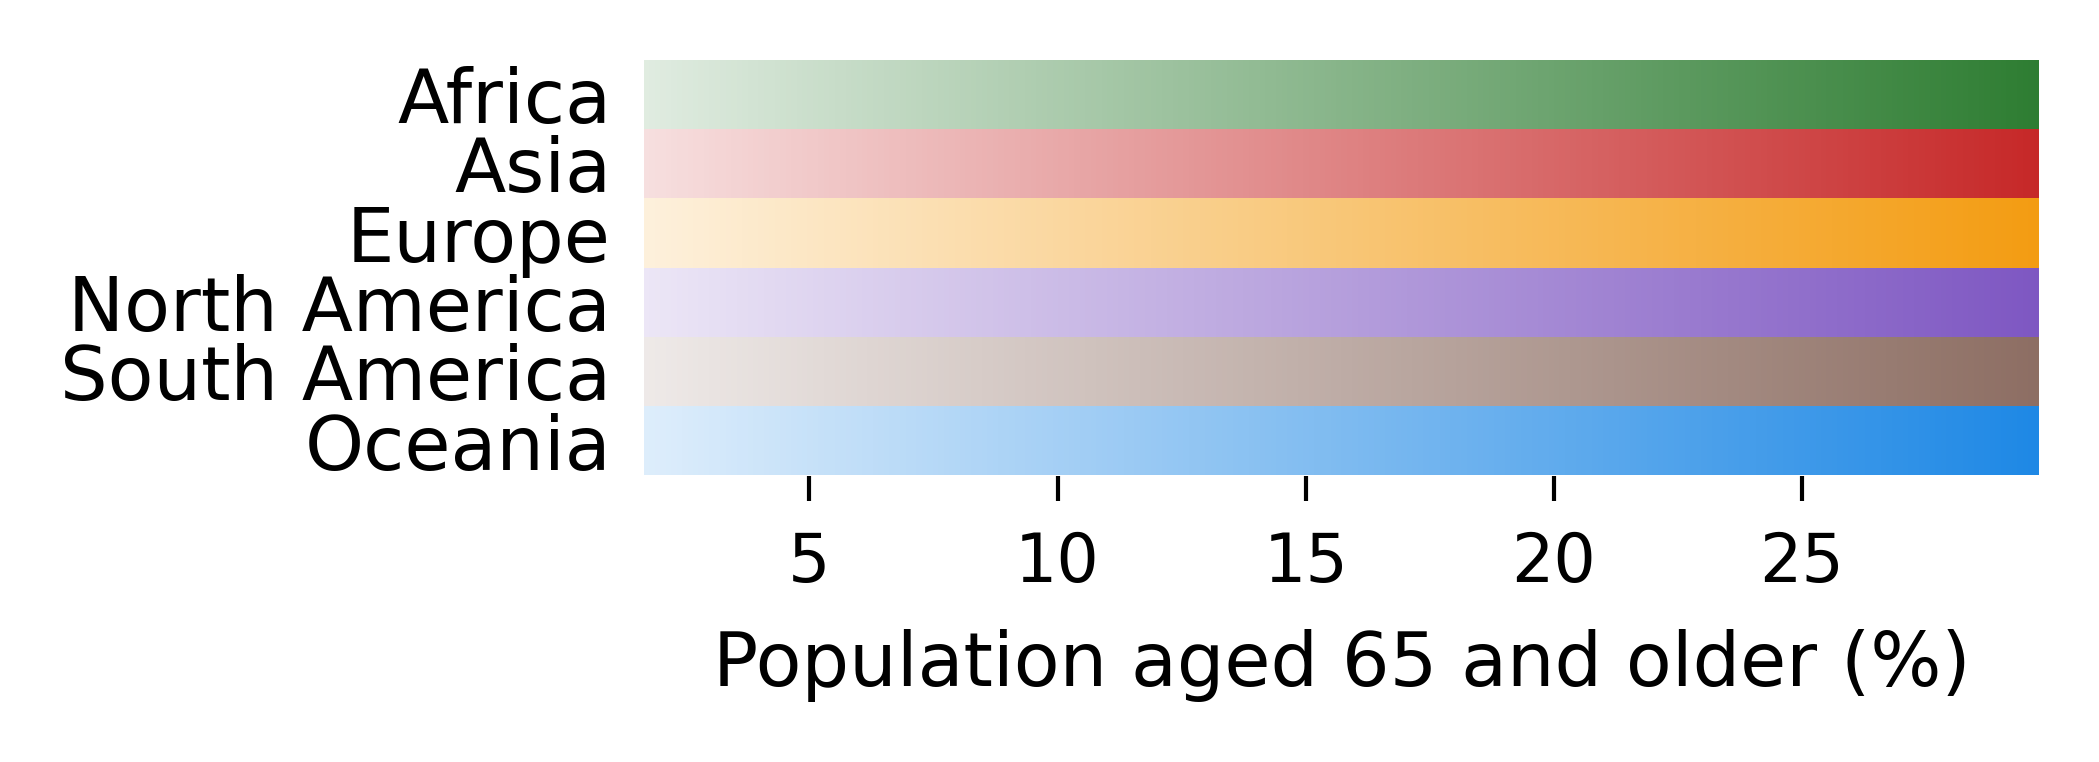

Saved legend: /Users/karwailin/Desktop/OAwalk/results/f2_worldmap/world_continent_legend.pdf


In [13]:
# ----------------------------
# 7) Continent legend (separate figure with gradients)
# ----------------------------
legend_order = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]

if "global_min" not in globals() or "global_max" not in globals():
    global_min = float(np.nanmin(g["aging_pct"]))
    global_max = float(np.nanmax(g["aging_pct"]))
    if not np.isfinite(global_min) or not np.isfinite(global_max) or global_max <= global_min:
        global_min, global_max = (0.0, 1.0)

x_vals = np.linspace(global_min, global_max, 256)

def _row_colors(continent: str) -> np.ndarray:
    base_hex = continent_colors.get(continent, "#E0E0E0")
    t = (x_vals - global_min) / (global_max - global_min)
    t = np.clip(t, 0.0, 1.0)
    colors = [_blend_color(base_hex, ti) for ti in t]
    return np.array([mcolors.to_rgb(c) for c in colors])[None, :, :]

fig, axes = plt.subplots(nrows=len(legend_order), ncols=1, figsize=(3, 0.9), sharex=True, dpi=600)
if len(legend_order) == 1:
    axes = [axes]

for ax, cont in zip(axes, legend_order):
    row = _row_colors(cont)
    ax.imshow(row, aspect="auto", extent=[global_min, global_max, 0, 1])
    ax.set_yticks([0.5])
    ax.set_yticklabels([cont], fontsize=9)
    ax.tick_params(axis="y", length=0, pad=4)
    ax.set_ylim(0, 1)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="x", labelsize=8, length=3, width=0.5)

axes[-1].set_xlabel("Population aged 65 and older (%)", fontsize=9)
plt.subplots_adjust(hspace=0.001)

legend_out = out_dir / "world_continent_legend.pdf"
plt.savefig(legend_out, bbox_inches="tight", pad_inches=0, transparent=True)
plt.show()

print("Saved legend:", legend_out)